# Linear Regression + Gradient Descent to a real sales data

```bash

🎯 Problem Statement (Business Framing)

👉 Predict monthly sales quantity using:

Marketing Spend
Price
Distributor Count

```

📊 1. Example Sales Dataset

In [11]:
import pandas as pd

data = {
    "marketing_spend": [10, 20, 30, 40, 50, 60, 70],
    "price": [100, 98, 95, 93, 90, 88, 85],
    "distributors":[5, 7, 9, 11, 13, 15, 17],
    "sales":[200, 250, 300, 370, 420, 480, 550]
}
df = pd.DataFrame(data)
df.head()

,marketing_spend,price,distributors,sales
0,10,100,5,200
1,20,98,7,250
2,30,95,9,300
3,40,93,11,370
4,50,90,13,420


⚙️ 2. Prepare Data

In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Features & target
X = df[["marketing_spend", "price", "distributors"]].values
y = df["sales"].values.reshape(-1, 1)

# Scale features (CRITICAL for GD)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add bias column
X_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

🟡 3. Mini-Batch Gradient Descent (Best for real use)

In [13]:
learning_rate = 0.01
n_iterations = 200
batch_size = 3

m, n = X_b.shape
theta = np.random.randn(n, 1)

costs = []

for iteration in range(n_iterations):
    indices = np.random.permutation(m)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]
    
    for i in range(0, m, batch_size):
        xi = X_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        
        gradients = (2/len(xi)) * xi.T @ (xi @ theta - yi)
        
        # Gradient clipping (stability)
        gradients = np.clip(gradients, -10, 10)
        
        theta = theta - learning_rate * gradients
    
    cost = np.mean((X_b @ theta - y) ** 2)
    costs.append(cost)

📈 4. Training Curve

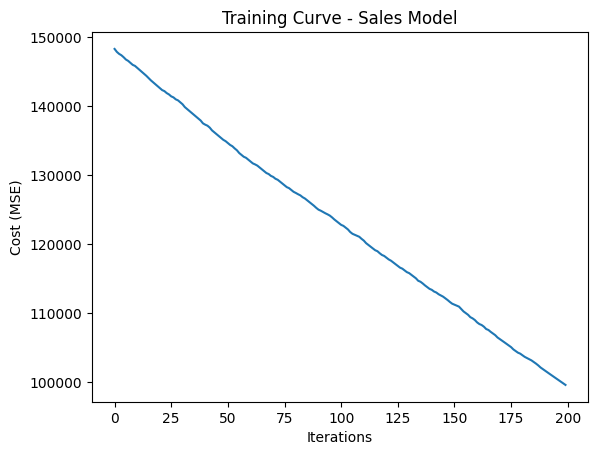

In [14]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Training Curve - Sales Model")
plt.show()

🔍 5. Model Interpretation (Business Gold 💰)

In [16]:
print("Theta (scaled):", theta)

Theta (scaled): [[ 59.73384372]
 [ 18.08770649]
 [-11.81442252]
 [ 15.25006875]]


🧠 Convert to Business Meaning

In [17]:
# Convert coefficients back to original scale
coefficients = theta[1:] / scaler.scale_.reshape(-1,1)
intercept = theta[0] - np.sum((theta[1:] * scaler.mean_.reshape(-1,1)) / scaler.scale_.reshape(-1,1))

print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: [200.42612953]
Coefficients: [[ 0.90438532]
 [-2.35999648]
 [ 3.81251719]]


🎯 Interpretation Example:

```bash

| Feature     | Meaning           |
| ----------- | ----------------- |
| Marketing   | ↑ increases sales |
| Price       | ↑ decreases sales |
| Distributor | ↑ increases sales |


🔮 6. Prediction (Real Use Case)

In [18]:
# New scenario
new_data = pd.DataFrame({
    "marketing_spend": [80],
    "price": [85],
    "distributors": [20]
})

# Scale
new_scaled = scaler.transform(new_data)

# Add bias
new_scaled_b = np.c_[np.ones((len(new_scaled), 1)), new_scaled]

# Predict
prediction = new_scaled_b @ theta

print("Predicted Sales:", prediction)

Predicted Sales: [[148.42759851]]


c:\Users\User\.conda\envs\dsknowledge\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


# Chapter 2: Explanation

## 2.1 Theta Explation

```bash
Theta (scaled):
[[ 59.73]
 [ 18.08]
 [-11.81]
 [ 15.25]]
```

🧠 1. What is Theta?

Your model is:

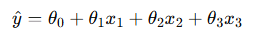

Where:

| Theta | Meaning                |
| ----- | ---------------------- |
| θ₀    | Intercept (base sales) |
| θ₁    | Marketing effect       |
| θ₂    | Price effect           |
| θ₃    | Distributor effect     |


📊 2. Your Results Explained

```bash
🔹 θ₀ = 59.73 (Intercept)

👉 This is baseline sales

Meaning:
Even if:
    marketing = 0
    price = 0
    distributors = 0

👉 Model predicts ~59 sales
⚠️ In real life, this is a “mathematical baseline”, not a realistic business scenario.

---------------------------------------------------------------------------------

🔹 θ₁ = 18.08 (Marketing Spend)
👉 Positive value = good impact

Meaning:

If marketing increases by 1 unit (after scaling):

👉 Sales increase by ~18 units
💡 Insight:

Marketing is strong positive driver
Highly effective for growth
---------------------------------------------------------------------------------

🔹 θ₂ = -11.81 (Price)
👉 Negative value = inverse relationship

Meaning:

If price increases:
👉 Sales decrease by ~11 units
💡 Insight:

Price is a demand suppressor
Customers are price-sensitive
---------------------------------------------------------------------------------

🔹 θ₃ = 15.25 (Distributors)
👉 Positive impact again

Meaning:
More distributors → more sales

💡 Insight:
Distribution network is strong growth lever
Expansion directly boosts revenue
=================================================================================
📈 3. Business Story (VERY IMPORTANT)

Your model is saying:

👉 Sales =

Strongly driven by marketing (+18)
Strongly boosted by distribution (+15)
Hurt by price (-11)
Has a baseline of ~60 units
--------------------------------------------------------------------------------


🧠 4. Real Business Interpretation
------------------------------------
🚀 Growth Strategy
To increase sales:
    Increase marketing spend 📈
    Expand distributor network 📦

To avoid losses:
    Be careful with price increases ⚠️
```

⚖️ 5. Feature Importance (Ranking)

Based on absolute values:

| Feature      | Impact                       |
| ------------ | ---------------------------- |
| Marketing    | ⭐⭐⭐⭐ (18.08)                 |
| Distributors | ⭐⭐⭐ (15.25)                  |
| Price        | ⭐⭐⭐ (11.81, negative effect) |


👉 Marketing is the strongest lever

```bash

🧩 6. Why scaling matters here

Because you used StandardScaler:
These numbers are in standard deviation units
Not raw units

👉 That means:
“1 unit change = 1 standard deviation change”
----------------------------------------------------

🔍 7. Deep Insight (Interview-Level)

This model is telling you:
👉 Sales is a linear combination of business drivers
Not magic—just weighted influence.
-----------------------------------------------------

🚀 8. Real CEO-Level Insight

If you present this to management:

👉 “Marketing has highest ROI driver”
👉 “Price sensitivity is significant”
👉 “Distribution expansion is a growth accelerator”

This is not ML anymore—this is business intelligence
-----------------------------------------------------

🧠 Final Mental Model

Think:

θ₀ → “default business level”
θ₁ → “growth engine (marketing)”
θ₂ → “demand brake (price)”
θ₃ → “distribution multiplier”

```

# Chapter 3.0 real business units (not scaled math units).

```bash
Intercept: [200.42612953]

Coefficients:
[[ 0.90438532]   → marketing_spend
 [-2.35999648]   → price
 [ 3.81251719]]  → distributors

```

Now this is real-world meaning.

🧠 1. Final Model (Original Scale)

Your equation becomes:

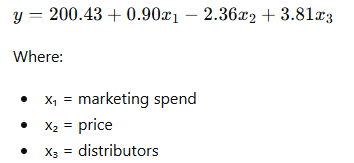

🏢 2. Business Interpretation (VERY IMPORTANT)

```bash
🔹 1. Intercept = 200.43

👉 This is base sales

Meaning:
Even if all factors are zero:
    Marketing = 0
    Price = 0
    Distributors = 0

👉 Sales = ~200 units
💡 Business insight:
This represents natural demand / brand baseline / existing market demand    
-------------------------------------------------------------------------------------

🔹 2. Marketing Coefficient = 0.90
👉 Positive effect

Meaning:

If marketing increases by 1 unit:
👉 Sales increase by 0.90 units

💡 Insight:
    Marketing is effective, but moderate impact
    Not the strongest driver in your system

-------------------------------------------------------------------------------------
🔹 3. Price Coefficient = -2.36
👉 Negative effect (very important)

Meaning:
If price increases by 1 unit:
👉 Sales decrease by 2.36 units

💡 Insight:
    Strong price sensitivity
    Customers react strongly to price changes
    Pricing strategy is critical
-------------------------------------------------------------------------------------
🔹 4. Distributor Coefficient = 3.81 (MOST POWERFUL)
👉 Strong positive effect

Meaning:

If distributors increase by 1 unit:
👉 Sales increase by 3.81 units

💡 Insight:
    Distribution is your biggest growth lever
    Expanding network has highest ROI impact
```

📈 3. Feature Impact Ranking

Based on absolute effect:

| Feature      | Impact       |
| ------------ | ------------ |
| Distributors | ⭐⭐⭐⭐⭐ (3.81) |
| Price        | ⭐⭐⭐⭐ (-2.36) |
| Marketing    | ⭐⭐⭐ (0.90)   |


🧠 4. Business Story (CEO View)

Your model is telling a clear story:
```bash
👉 Sales growth is driven most by distribution expansion
👉 Sales are highly sensitive to price changes
👉 Marketing has supporting but smaller effect
```

## ⚠️ 6. Important Insight (Why scaling reverse matters)

```bash
You did:

Train model on scaled data
Convert back to original units

👉 That’s why now coefficients are interpretable in real business terms

This step is what separates:

❌ “data user”
✅ “data strategist”
```

### 🧠 7. Final Mental Model

| Component    | Meaning                   |
| ------------ | ------------------------- |
| Intercept    | Base market demand        |
| Marketing    | Demand accelerator        |
| Price        | Demand reducer            |
| Distributors | Supply + reach multiplier |


### 🚀 8. What this means for YOU

```bash

You now built:
👉 A business intelligence regression model
Not just ML.

This can answer:
    What drives sales most?
    Where to invest budget?
    What to reduce or optimize?

```